## A. Coordinate Placing

In [1]:
from pathlib import Path

GROUND_FILE = Path("/content/Ground_01.png")
SAPLING_FILE = Path("/content/Sapling_01_01.png")
TREE_FILE = Path("/content/Tree_01_01.png")

for file in [GROUND_FILE, SAPLING_FILE, TREE_FILE]:
    if not file.exists():
        raise FileNotFoundError(f"File not found: {file}")

print("All files found.")

All files found.



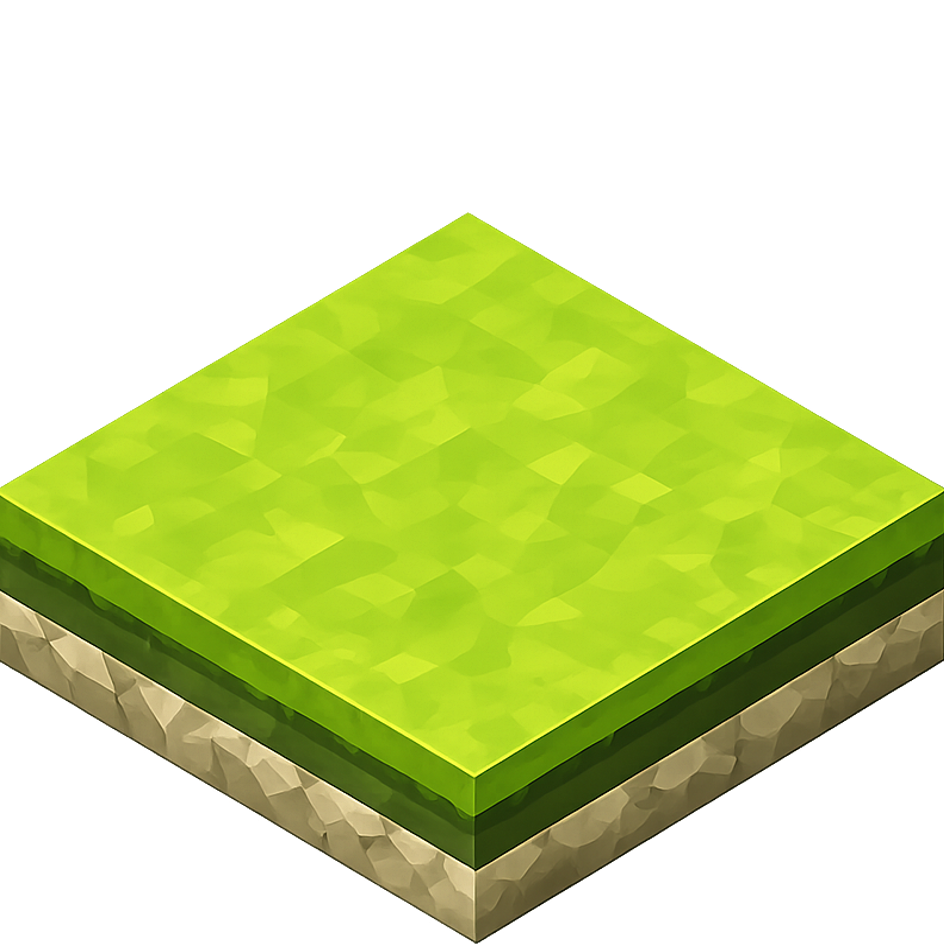
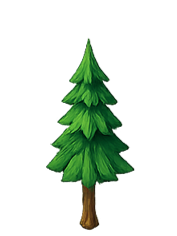
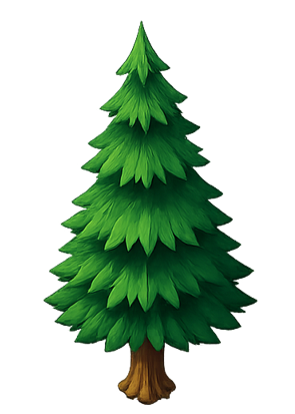

In [3]:
import base64
from pathlib import Path
from IPython.display import HTML, display
from PIL import Image

GROUND_FILE = Path("/content/Ground_01.png")
SAPLING_FILE = Path("/content/Sapling_01_01.png")
TREE_FILE = Path("/content/Tree_01_01.png")

for file in [GROUND_FILE, SAPLING_FILE, TREE_FILE]:
    if not file.exists():
        raise FileNotFoundError(f"Missing file: {file}")

with Image.open(GROUND_FILE) as img:
    ground_width, ground_height = img.size

with Image.open(SAPLING_FILE) as img:
    sapling_width, sapling_height = img.size

with Image.open(TREE_FILE) as img:
    tree_width, tree_height = img.size

def to_base64(path):
    return base64.b64encode(path.read_bytes()).decode("utf-8")

ground_b64 = to_base64(GROUND_FILE)
sapling_b64 = to_base64(SAPLING_FILE)
tree_b64 = to_base64(TREE_FILE)

row_layout = [
    [1, 3, 5, 13],
    [9, 2, 15, 18],
    [6, 17, 8, 12],
    [4, 11, 19, 16],
    [10, 20, 7, 14],
]

render_order = [
    1, 3, 5, 13,
    9, 2, 15, 18,
    6, 17, 8, 12,
    4, 11, 19, 16,
    10, 20, 7, 14
]

initial_positions = {}

row_y = [0.27, 0.36, 0.45, 0.54, 0.63]
normal_x = [0.29, 0.43, 0.57, 0.71]
shifted_x = [0.34, 0.48, 0.62, 0.76]

for row_index, slots in enumerate(row_layout):
    xs = shifted_x if row_index % 2 == 1 else normal_x

    for slot, x_norm in zip(slots, xs):
        initial_positions[slot] = {
            "x": round(x_norm * ground_width),
            "y": round(row_y[row_index] * ground_height),
        }

html = f"""
<div style="font-family: Arial, sans-serif;">
  <h3>MySkillForest – Tree Slot Coordinate Editor</h3>

  <div style="display:flex; gap:10px; flex-wrap:wrap; margin-bottom:12px;">
    <label>
      Preview:
      <select id="preview-mode" onchange="updatePreviewMode()">
        <option value="marker">Markers only</option>
        <option value="sapling">Saplings only</option>
        <option value="tree">Mature trees only</option>
        <option value="sapling-marker">Saplings + markers</option>
        <option value="tree-marker">Mature trees + markers</option>
      </select>
    </label>

    <label>
      Asset scale:
      <input
        id="asset-scale"
        type="range"
        min="0.50"
        max="1.50"
        value="1.00"
        step="0.01"
        oninput="updateAssetScale()"
      />
      <span id="scale-label">1.00×</span>
    </label>
  </div>

  <div
    id="patch-editor"
    style="
      position:relative;
      width:min(90vw, {ground_width}px);
      aspect-ratio:{ground_width}/{ground_height};
      border:1px solid #999;
      overflow:visible;
      user-select:none;
      touch-action:none;
      background:#ddd;
    "
  >
    <img
      src="data:image/png;base64,{ground_b64}"
      style="
        position:absolute;
        inset:0;
        width:100%;
        height:100%;
        object-fit:contain;
        pointer-events:none;
      "
    />
  </div>

  <div style="margin-top:12px;">
    <button onclick="downloadCSV()">Download CSV</button>
    <button onclick="downloadJSON()">Download JSON</button>
    <button onclick="copyCoordinates()">Copy Coordinates</button>
    <button onclick="resetMarkers()">Reset</button>
  </div>

  <pre
    id="coordinate-output"
    style="
      margin-top:12px;
      max-height:300px;
      overflow:auto;
      background:#f3f3f3;
      padding:10px;
    "
  ></pre>
</div>

<script>
const nativeWidth = {ground_width};
const nativeHeight = {ground_height};

const saplingNativeWidth = {sapling_width};
const saplingNativeHeight = {sapling_height};

const treeNativeWidth = {tree_width};
const treeNativeHeight = {tree_height};

const initialPositions = {initial_positions};
const positions = JSON.parse(JSON.stringify(initialPositions));

const renderOrder = {render_order};

const editor = document.getElementById("patch-editor");
const output = document.getElementById("coordinate-output");

let previewMode = "marker";
let assetScale = 1.0;

function nativeToScreenX(x) {{
  return x / nativeWidth * editor.clientWidth;
}}

function nativeToScreenY(y) {{
  return y / nativeHeight * editor.clientHeight;
}}

function screenToNativeX(x) {{
  return Math.round(x / editor.clientWidth * nativeWidth);
}}

function screenToNativeY(y) {{
  return Math.round(y / editor.clientHeight * nativeHeight);
}}

function getGroundScale() {{
  return editor.clientWidth / nativeWidth;
}}

function createSlot(slot) {{
  const wrapper = document.createElement("div");
  wrapper.className = "slot-wrapper";
  wrapper.dataset.slot = slot;

  Object.assign(wrapper.style, {{
    position: "absolute",
    left: "0px",
    top: "0px",
    zIndex: String(renderOrder.indexOf(slot) + 1)
  }});

  const preview = document.createElement("img");
  preview.className = "tree-preview";
  preview.draggable = false;

  Object.assign(preview.style, {{
    position: "absolute",
    left: "0px",
    top: "0px",
    transform: "translate(-50%, -100%)",
    transformOrigin: "50% 100%",
    pointerEvents: "none",
    objectFit: "contain"
  }});

  const marker = document.createElement("div");
  marker.className = "slot-marker";
  marker.textContent = slot;

  Object.assign(marker.style, {{
    position: "absolute",
    left: "0px",
    top: "0px",
    width: "28px",
    height: "28px",
    borderRadius: "50%",
    background: "rgba(255,255,255,0.90)",
    border: "2px solid black",
    display: "flex",
    alignItems: "center",
    justifyContent: "center",
    fontWeight: "bold",
    fontSize: "12px",
    cursor: "grab",
    transform: "translate(-50%, -50%)",
    zIndex: "1000"
  }});

  marker.addEventListener("pointerdown", event => {{
    event.preventDefault();
    marker.setPointerCapture(event.pointerId);
    marker.style.cursor = "grabbing";
  }});

  marker.addEventListener("pointermove", event => {{
    if (!marker.hasPointerCapture(event.pointerId)) return;

    const rect = editor.getBoundingClientRect();

    const screenX = Math.max(
      0,
      Math.min(editor.clientWidth, event.clientX - rect.left)
    );

    const screenY = Math.max(
      0,
      Math.min(editor.clientHeight, event.clientY - rect.top)
    );

    positions[slot].x = screenToNativeX(screenX);
    positions[slot].y = screenToNativeY(screenY);

    positionSlot(wrapper);
    updateOutput();
  }});

  marker.addEventListener("pointerup", event => {{
    marker.releasePointerCapture(event.pointerId);
    marker.style.cursor = "grab";
  }});

  wrapper.appendChild(preview);
  wrapper.appendChild(marker);
  editor.appendChild(wrapper);
}}

function positionSlot(wrapper) {{
  const slot = Number(wrapper.dataset.slot);

  wrapper.style.left = nativeToScreenX(positions[slot].x) + "px";
  wrapper.style.top = nativeToScreenY(positions[slot].y) + "px";
}}

function updatePreviewMode() {{
  previewMode = document.getElementById("preview-mode").value;
  updateAllSlots();
}}

function updateAssetScale() {{
  assetScale = Number(document.getElementById("asset-scale").value);
  document.getElementById("scale-label").textContent =
    assetScale.toFixed(2) + "×";

  updateAllSlots();
}}

function updateSlotAppearance(wrapper) {{
  const preview = wrapper.querySelector(".tree-preview");
  const marker = wrapper.querySelector(".slot-marker");

  const showSapling =
    previewMode === "sapling" ||
    previewMode === "sapling-marker";

  const showTree =
    previewMode === "tree" ||
    previewMode === "tree-marker";

  const showMarker =
    previewMode === "marker" ||
    previewMode === "sapling-marker" ||
    previewMode === "tree-marker";

  if (showSapling) {{
    preview.src = "data:image/png;base64,{sapling_b64}";
    preview.style.display = "block";

    const scale = getGroundScale() * assetScale;
    preview.style.width = (saplingNativeWidth * scale) + "px";
    preview.style.height = (saplingNativeHeight * scale) + "px";
  }}
  else if (showTree) {{
    preview.src = "data:image/png;base64,{tree_b64}";
    preview.style.display = "block";

    const scale = getGroundScale() * assetScale;
    preview.style.width = (treeNativeWidth * scale) + "px";
    preview.style.height = (treeNativeHeight * scale) + "px";
  }}
  else {{
    preview.style.display = "none";
  }}

  marker.style.display = showMarker ? "flex" : "none";
}}

function updateAllSlots() {{
  document.querySelectorAll(".slot-wrapper").forEach(wrapper => {{
    positionSlot(wrapper);
    updateSlotAppearance(wrapper);
  }});

  updateOutput();
}}

function getCoordinateRows() {{
  return renderOrder.map((slot, index) => ({{
    Display_Slot: slot,
    X_Pixel: positions[slot].x,
    Y_Pixel: positions[slot].y,
    X_Normalized: +(positions[slot].x / nativeWidth).toFixed(6),
    Y_Normalized: +(positions[slot].y / nativeHeight).toFixed(6),
    Render_Order: index + 1
  }}));
}}

function updateOutput() {{
  output.textContent = JSON.stringify(getCoordinateRows(), null, 2);
}}

function downloadText(filename, text, mimeType) {{
  const blob = new Blob([text], {{type:mimeType}});
  const url = URL.createObjectURL(blob);

  const link = document.createElement("a");
  link.href = url;
  link.download = filename;
  link.click();

  URL.revokeObjectURL(url);
}}

function downloadCSV() {{
  const rows = getCoordinateRows();

  const headers = [
    "Display_Slot",
    "X_Pixel",
    "Y_Pixel",
    "X_Normalized",
    "Y_Normalized",
    "Render_Order"
  ];

  const csv = [
    headers.join(","),
    ...rows.map(row =>
      headers.map(header => row[header]).join(",")
    )
  ].join("\\n");

  downloadText("tree_slots.csv", csv, "text/csv");
}}

function downloadJSON() {{
  downloadText(
    "tree_slots.json",
    JSON.stringify(getCoordinateRows(), null, 2),
    "application/json"
  );
}}

async function copyCoordinates() {{
  await navigator.clipboard.writeText(
    JSON.stringify(getCoordinateRows(), null, 2)
  );

  alert("Coordinates copied.");
}}

function resetMarkers() {{
  Object.keys(initialPositions).forEach(slot => {{
    positions[slot] = {{...initialPositions[slot]}};
  }});

  updateAllSlots();
}}

renderOrder.forEach(createSlot);
updateAllSlots();

window.addEventListener("resize", updateAllSlots);
</script>
"""

display(HTML(html))

## B. Single Patch Test Evaluation

In [5]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

ASSET_DIR = Path("/content")
SLOT_FILE = ASSET_DIR / "tree_slots.json"

# Tree and sapling images are displayed at 70% of their exported size.
ASSET_SCALE = 0.70

STYLE_NAMES = {
    "01": "Classic Greens",
    "02": "Autumn Walk",
    "03": "Frosty Forest",
    "04": "Fruit Foliage",
    "05": "Mystical Tangle",
    "06": "Wicked Woods",
    "07": "Sakura Season",
    "08": "Bamboo Thicket",
    "09": "Industrial Zone",
}

In [6]:
required_files = [SLOT_FILE]

for style_id in STYLE_NAMES:
    required_files.append(ASSET_DIR / f"Ground_{style_id}.png")

    for tree_style in range(1, 4):
        required_files.append(
            ASSET_DIR / f"Sapling_{style_id}_{tree_style:02d}.png"
        )
        required_files.append(
            ASSET_DIR / f"Tree_{style_id}_{tree_style:02d}.png"
        )

missing_files = [path.name for path in required_files if not path.exists()]

if missing_files:
    print("Missing files:")
    for filename in missing_files:
        print(f" - {filename}")
else:
    print("All assets were found.")

All assets were found.


In [7]:
with open(SLOT_FILE, "r", encoding="utf-8") as file:
    slot_records = json.load(file)

slot_lookup = {
    int(record["Display_Slot"]): record
    for record in slot_records
}

render_order = [
    int(record["Display_Slot"])
    for record in sorted(
        slot_records,
        key=lambda record: int(record["Render_Order"])
    )
]

print("Planting slots loaded:", len(slot_lookup))
print("Layer order:", render_order)

Planting slots loaded: 20
Layer order: [1, 3, 5, 13, 9, 2, 15, 18, 6, 17, 8, 12, 4, 11, 19, 16, 10, 20, 7, 14]


In [8]:
def get_tree_asset_number(display_slot: int) -> int:
    """
    Slots 1, 4, 7, ... use asset 01.
    Slots 2, 5, 8, ... use asset 02.
    Slots 3, 6, 9, ... use asset 03.
    """
    return ((display_slot - 1) % 3) + 1


def load_rgba(path: Path) -> Image.Image:
    return Image.open(path).convert("RGBA")


def resize_asset(image: Image.Image, scale: float) -> Image.Image:
    width = max(1, round(image.width * scale))
    height = max(1, round(image.height * scale))

    return image.resize(
        (width, height),
        Image.Resampling.LANCZOS
    )


def place_bottom_center(
    canvas: Image.Image,
    asset: Image.Image,
    anchor_x: float,
    anchor_y: float,
) -> None:
    """
    Places the bottom-center of the transparent PNG at the planting coordinate.
    """
    left = round(anchor_x - asset.width / 2)
    top = round(anchor_y - asset.height)

    canvas.alpha_composite(asset, dest=(left, top))


def render_patch(
    style_id: str,
    planted_count: int,
    growth_stage: str = "Sapling",
) -> Image.Image:

    ground_path = ASSET_DIR / f"Ground_{style_id}.png"
    canvas = load_rgba(ground_path)

    planted_slots = set(range(1, planted_count + 1))

    # Draw according to the fixed back-to-front layer order.
    for display_slot in render_order:

        if display_slot not in planted_slots:
            continue

        asset_number = get_tree_asset_number(display_slot)

        if growth_stage == "Mature Tree":
            asset_path = (
                ASSET_DIR
                / f"Tree_{style_id}_{asset_number:02d}.png"
            )
        else:
            asset_path = (
                ASSET_DIR
                / f"Sapling_{style_id}_{asset_number:02d}.png"
            )

        asset = resize_asset(
            load_rgba(asset_path),
            ASSET_SCALE
        )

        slot = slot_lookup[display_slot]

        # Use normalized coordinates so placement still works
        # if the ground dimensions are changed consistently.
        anchor_x = float(slot["X_Normalized"]) * canvas.width
        anchor_y = float(slot["Y_Normalized"]) * canvas.height

        place_bottom_center(
            canvas=canvas,
            asset=asset,
            anchor_x=anchor_x,
            anchor_y=anchor_y,
        )

    return canvas

In [9]:
style_dropdown = widgets.Dropdown(
    options=[
        (f"{style_id} – {name}", style_id)
        for style_id, name in STYLE_NAMES.items()
    ],
    value="01",
    description="Style:",
    style={"description_width": "initial"},
)

tree_count_slider = widgets.IntSlider(
    value=1,
    min=0,
    max=20,
    step=1,
    description="Trees planted:",
    continuous_update=False,
    style={"description_width": "initial"},
)

stage_dropdown = widgets.Dropdown(
    options=["Sapling", "Mature Tree"],
    value="Sapling",
    description="Preview stage:",
    style={"description_width": "initial"},
)

preview_output = widgets.Output()


def update_preview(*_):
    with preview_output:
        clear_output(wait=True)

        rendered = render_patch(
            style_id=style_dropdown.value,
            planted_count=tree_count_slider.value,
            growth_stage=stage_dropdown.value,
        )

        plt.figure(figsize=(9, 9))
        plt.imshow(rendered)
        plt.axis("off")
        plt.title(
            f"{STYLE_NAMES[style_dropdown.value]} — "
            f"{tree_count_slider.value} planted trees — "
            f"{stage_dropdown.value}"
        )
        plt.show()


style_dropdown.observe(update_preview, names="value")
tree_count_slider.observe(update_preview, names="value")
stage_dropdown.observe(update_preview, names="value")

controls = widgets.VBox([
    style_dropdown,
    tree_count_slider,
    stage_dropdown,
])

display(controls, preview_output)
update_preview()

Output()

## C. Multi-Patch Testing

In [10]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

ASSET_DIR = Path("/content")
SLOT_FILE = ASSET_DIR / "tree_slots.json"

# Tree and sapling images are displayed at 70% of their exported size.
ASSET_SCALE = 0.70

STYLE_NAMES = {
    "01": "Classic Greens",
    "02": "Autumn Walk",
    "03": "Frosty Forest",
    "04": "Fruit Foliage",
    "05": "Mystical Tangle",
    "06": "Wicked Woods",
    "07": "Sakura Season",
    "08": "Bamboo Thicket",
    "09": "Industrial Zone",
}

required_files = [SLOT_FILE]

for style_id in STYLE_NAMES:
    required_files.append(ASSET_DIR / f"Ground_{style_id}.png")

    for tree_style in range(1, 4):
        required_files.append(
            ASSET_DIR / f"Sapling_{style_id}_{tree_style:02d}.png"
        )
        required_files.append(
            ASSET_DIR / f"Tree_{style_id}_{tree_style:02d}.png"
        )

missing_files = [path.name for path in required_files if not path.exists()]

if missing_files:
    print("Missing files:")
    for filename in missing_files:
        print(f" - {filename}")
else:
    print("All assets were found.")

with open(SLOT_FILE, "r", encoding="utf-8") as file:
    slot_records = json.load(file)

slot_lookup = {
    int(record["Display_Slot"]): record
    for record in slot_records
}

render_order = [
    int(record["Display_Slot"])
    for record in sorted(
        slot_records,
        key=lambda record: int(record["Render_Order"])
    )
]

print("Planting slots loaded:", len(slot_lookup))
print("Layer order:", render_order)

def get_tree_asset_number(display_slot: int) -> int:
    """
    Slots 1, 4, 7, ... use asset 01.
    Slots 2, 5, 8, ... use asset 02.
    Slots 3, 6, 9, ... use asset 03.
    """
    return ((display_slot - 1) % 3) + 1


def load_rgba(path: Path) -> Image.Image:
    return Image.open(path).convert("RGBA")


def resize_asset(image: Image.Image, scale: float) -> Image.Image:
    width = max(1, round(image.width * scale))
    height = max(1, round(image.height * scale))

    return image.resize(
        (width, height),
        Image.Resampling.LANCZOS
    )


def place_bottom_center(
    canvas: Image.Image,
    asset: Image.Image,
    anchor_x: float,
    anchor_y: float,
) -> None:
    """
    Places the bottom-center of the transparent PNG at the planting coordinate.
    """
    left = round(anchor_x - asset.width / 2)
    top = round(anchor_y - asset.height)

    canvas.alpha_composite(asset, dest=(left, top))


def render_patch(
    style_id: str,
    planted_count: int,
    growth_stage: str = "Sapling",
) -> Image.Image:

    ground_path = ASSET_DIR / f"Ground_{style_id}.png"
    canvas = load_rgba(ground_path)

    planted_slots = set(range(1, planted_count + 1))

    # Draw according to the fixed back-to-front layer order.
    for display_slot in render_order:

        if display_slot not in planted_slots:
            continue

        asset_number = get_tree_asset_number(display_slot)

        if growth_stage == "Mature Tree":
            asset_path = (
                ASSET_DIR
                / f"Tree_{style_id}_{asset_number:02d}.png"
            )
        else:
            asset_path = (
                ASSET_DIR
                / f"Sapling_{style_id}_{asset_number:02d}.png"
            )

        asset = resize_asset(
            load_rgba(asset_path),
            ASSET_SCALE
        )

        slot = slot_lookup[display_slot]

        # Use normalized coordinates so placement still works
        # if the ground dimensions are changed consistently.
        anchor_x = float(slot["X_Normalized"]) * canvas.width
        anchor_y = float(slot["Y_Normalized"]) * canvas.height

        place_bottom_center(
            canvas=canvas,
            asset=asset,
            anchor_x=anchor_x,
            anchor_y=anchor_y,
        )

    return canvas

All assets were found.
Planting slots loaded: 20
Layer order: [1, 3, 5, 13, 9, 2, 15, 18, 6, 17, 8, 12, 4, 11, 19, 16, 10, 20, 7, 14]


In [11]:
from pathlib import Path
import base64
import json
from PIL import Image
from IPython.display import HTML, display

ASSET_DIR = Path("/content")

def generate_hex_spiral(max_patches=37):
    """
    Generate pointy-top hex-grid coordinates:
    center first, followed by outward rings.
    """

    coordinates = [(0, 0)]

    # Six axial directions
    directions = [
        (1, 0),
        (0, 1),
        (-1, 1),
        (-1, 0),
        (0, -1),
        (1, -1),
    ]

    radius = 1

    while len(coordinates) < max_patches:
        # Start each ring at the upper-left side
        q, r = 0, -radius

        for direction_q, direction_r in directions:
            for _ in range(radius):
                if len(coordinates) >= max_patches:
                    break

                coordinates.append((q, r))
                q += direction_q
                r += direction_r

        radius += 1

    return coordinates[:max_patches]


PATCH_COORDINATES = generate_hex_spiral(37)

for patch_number, coordinate in enumerate(PATCH_COORDINATES[:20], start=1):
    print(f"Patch {patch_number:02d}: {coordinate}")

Patch 01: (0, 0)
Patch 02: (0, -1)
Patch 03: (1, -1)
Patch 04: (1, 0)
Patch 05: (0, 1)
Patch 06: (-1, 1)
Patch 07: (-1, 0)
Patch 08: (0, -2)
Patch 09: (1, -2)
Patch 10: (2, -2)
Patch 11: (2, -1)
Patch 12: (2, 0)
Patch 13: (1, 1)
Patch 14: (0, 2)
Patch 15: (-1, 2)
Patch 16: (-2, 2)
Patch 17: (-2, 1)
Patch 18: (-2, 0)
Patch 19: (-1, -1)
Patch 20: (0, -3)


In [12]:
def image_to_base64(path: Path) -> str:
    return base64.b64encode(path.read_bytes()).decode("utf-8")


ground_assets = {}

for style_id in STYLE_NAMES:
    path = ASSET_DIR / f"Ground_{style_id}.png"

    if not path.exists():
        raise FileNotFoundError(f"Missing ground asset: {path.name}")

    with Image.open(path) as image:
        width, height = image.size

    ground_assets[style_id] = {
        "base64": image_to_base64(path),
        "width": width,
        "height": height,
    }


reference_width = ground_assets["01"]["width"]
reference_height = ground_assets["01"]["height"]

patch_coordinate_data = [
    {
        "patchNumber": index + 1,
        "q": coordinate[0],
        "r": coordinate[1],
    }
    for index, coordinate in enumerate(PATCH_COORDINATES)
]


html = f"""
<div style="font-family:Arial,sans-serif;">
  <h3>MySkillForest – Multi-Patch Placement Prototype</h3>

  <div style="
      display:flex;
      flex-wrap:wrap;
      gap:16px;
      margin-bottom:14px;
      align-items:center;
  ">
    <label>
      Number of patches:
      <input
        id="patch-count"
        type="range"
        min="1"
        max="37"
        value="7"
        step="1"
      />
      <span id="patch-count-label">7</span>
    </label>

    <label>
      Horizontal spacing:
      <input
        id="x-spacing"
        type="range"
        min="300"
        max="1000"
        value="690"
        step="5"
      />
      <span id="x-spacing-label">690</span>
    </label>

    <label>
      Vertical spacing:
      <input
        id="y-spacing"
        type="range"
        min="250"
        max="900"
        value="520"
        step="5"
      />
      <span id="y-spacing-label">520</span>
    </label>

    <label>
      Patch scale:
      <input
        id="patch-scale"
        type="range"
        min="0.30"
        max="1.00"
        value="0.55"
        step="0.01"
      />
      <span id="patch-scale-label">0.55×</span>
    </label>

    <button id="reset-camera">Reset camera</button>
  </div>

  <p style="margin:6px 0 12px 0;">
    Drag inside the viewport to pan. Patch numbers are temporary guides.
  </p>

  <div
    id="viewport"
    style="
      position:relative;
      width:100%;
      height:680px;
      overflow:hidden;
      border:1px solid #888;
      background:#c8e5ed;
      cursor:grab;
      user-select:none;
      touch-action:none;
    "
  >
    <div
      id="world"
      style="
        position:absolute;
        left:50%;
        top:50%;
        transform:translate(0px, 0px);
        transform-origin:0 0;
      "
    ></div>
  </div>

  <pre
    id="placement-output"
    style="
      margin-top:12px;
      max-height:240px;
      overflow:auto;
      padding:10px;
      background:#f3f3f3;
    "
  ></pre>
</div>

<script>
const groundAssets = {json.dumps(ground_assets)};
const patchCoordinates = {json.dumps(patch_coordinate_data)};

const nativePatchWidth = {reference_width};
const nativePatchHeight = {reference_height};

const viewport = document.getElementById("viewport");
const world = document.getElementById("world");
const output = document.getElementById("placement-output");

const patchCountInput = document.getElementById("patch-count");
const xSpacingInput = document.getElementById("x-spacing");
const ySpacingInput = document.getElementById("y-spacing");
const patchScaleInput = document.getElementById("patch-scale");

let cameraX = 0;
let cameraY = 0;

let dragging = false;
let dragStartX = 0;
let dragStartY = 0;
let cameraStartX = 0;
let cameraStartY = 0;

function getSettings() {{
  return {{
    patchCount: Number(patchCountInput.value),
    xSpacing: Number(xSpacingInput.value),
    ySpacing: Number(ySpacingInput.value),
    patchScale: Number(patchScaleInput.value),
  }};
}}

function axialToWorld(q, r, xSpacing, ySpacing) {{
  /*
    Pointy-top hex mapping.

    q controls the main horizontal movement.
    r contributes both horizontal and vertical movement.
  */
  return {{
    x: q * xSpacing + r * (xSpacing / 2),
    y: r * ySpacing,
  }};
}}

function getStyleId(patchNumber) {{
  return String(((patchNumber - 1) % 9) + 1).padStart(2, "0");
}}

function renderWorld() {{
  const settings = getSettings();

  world.innerHTML = "";

  const placements = [];

  patchCoordinates
    .slice(0, settings.patchCount)
    .forEach(record => {{
      const worldPosition = axialToWorld(
        record.q,
        record.r,
        settings.xSpacing,
        settings.ySpacing
      );

      const styleId = getStyleId(record.patchNumber);
      const asset = groundAssets[styleId];

      const patch = document.createElement("div");

      patch.style.position = "absolute";
      patch.style.left = worldPosition.x + "px";
      patch.style.top = worldPosition.y + "px";
      patch.style.width =
        nativePatchWidth * settings.patchScale + "px";
      patch.style.height =
        nativePatchHeight * settings.patchScale + "px";
      patch.style.transform = "translate(-50%, -50%)";

      /*
        Temporary patch layer ordering.
        Higher patches are drawn first, lower patches later.
      */
      patch.style.zIndex =
        String(Math.round(worldPosition.y + 100000));

      const image = document.createElement("img");
      image.src = "data:image/png;base64," + asset.base64;

      Object.assign(image.style, {{
        position: "absolute",
        inset: "0",
        width: "100%",
        height: "100%",
        objectFit: "contain",
        pointerEvents: "none",
      }});

      const label = document.createElement("div");
      label.textContent = record.patchNumber;

      Object.assign(label.style, {{
        position: "absolute",
        left: "50%",
        top: "48%",
        transform: "translate(-50%, -50%)",
        width: "34px",
        height: "34px",
        borderRadius: "50%",
        background: "rgba(255,255,255,0.88)",
        border: "2px solid #222",
        display: "flex",
        alignItems: "center",
        justifyContent: "center",
        fontWeight: "bold",
        pointerEvents: "none",
      }});

      patch.appendChild(image);
      patch.appendChild(label);
      world.appendChild(patch);

      placements.push({{
        Patch_Order: record.patchNumber,
        Hex_Q: record.q,
        Hex_R: record.r,
        World_X: Math.round(worldPosition.x),
        World_Y: Math.round(worldPosition.y),
        Style_ID: styleId,
      }});
    }});

  output.textContent = JSON.stringify(
    {{
      settings,
      placements,
    }},
    null,
    2
  );

  updateLabels();
}}

function updateCamera() {{
  world.style.transform =
    `translate(${{cameraX}}px, ${{cameraY}}px)`;
}}

function resetCamera() {{
  cameraX = 0;
  cameraY = 0;
  updateCamera();
}}

function updateLabels() {{
  const settings = getSettings();

  document.getElementById("patch-count-label").textContent =
    settings.patchCount;

  document.getElementById("x-spacing-label").textContent =
    settings.xSpacing;

  document.getElementById("y-spacing-label").textContent =
    settings.ySpacing;

  document.getElementById("patch-scale-label").textContent =
    settings.patchScale.toFixed(2) + "×";
}}

[
  patchCountInput,
  xSpacingInput,
  ySpacingInput,
  patchScaleInput
].forEach(input => {{
  input.addEventListener("input", renderWorld);
}});

viewport.addEventListener("pointerdown", event => {{
  dragging = true;

  dragStartX = event.clientX;
  dragStartY = event.clientY;

  cameraStartX = cameraX;
  cameraStartY = cameraY;

  viewport.setPointerCapture(event.pointerId);
  viewport.style.cursor = "grabbing";
}});

viewport.addEventListener("pointermove", event => {{
  if (!dragging) return;

  cameraX = cameraStartX + event.clientX - dragStartX;
  cameraY = cameraStartY + event.clientY - dragStartY;

  updateCamera();
}});

viewport.addEventListener("pointerup", event => {{
  dragging = false;
  viewport.releasePointerCapture(event.pointerId);
  viewport.style.cursor = "grab";
}});

document
  .getElementById("reset-camera")
  .addEventListener("click", resetCamera);

renderWorld();
resetCamera();
</script>
"""

display(HTML(html))

Output hidden; open in https://colab.research.google.com to view.